# Exercise 2: PM2.5 Prediction with GNNs

This notebook predicts PM2.5 for London Output Areas using graph neural networks.
It prepares a kNN graph from OA centroids, trains GCN and GraphSAGE models, and compares their performance using RMSE and R2.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv

## 1. Load and inspect data

In [2]:
geojson_path = "AssignmentData-LondonPM25Prediction.geojson"

gdf = gpd.read_file(geojson_path)

print("Shape:", gdf.shape)
print("CRS:", gdf.crs)
print("First 15 columns:", gdf.columns.tolist()[:15])
print(gdf[["oa_code", "PM25"]].head())

gdf.head(2)

Shape: (25053, 63)
CRS: EPSG:27700
First 15 columns: ['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT']
     oa_code       PM25
0  E00023264  16.037363
1  E00003359  15.571575
2  E00023266  16.068834
3  E00020264  18.205215
4  E00023263  16.128491


,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k052_PCT,k053_PCT,k054_PCT,k055_PCT,k056_PCT,k057_PCT,k058_PCT,k059_PCT,k060_PCT,geometry
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.801915,0.574316,0.565354,0.693873,0.607090,0.478002,0.509235,0.638862,0.662914,"MULTIPOLYGON (((527635.452 171810.058, 527495...."
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.731722,0.346726,0.750254,0.730786,0.669715,0.548814,0.621092,0.667940,0.558571,"MULTIPOLYGON (((543581.516 171132.486, 543704 ..."


# 2. Prepare features and target

In [3]:
id_col = "oa_code"
target_col = "PM25"

feature_cols = [c for c in gdf.columns if c not in [id_col, target_col, "geometry"]]

print("Number of feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Last 10 feature columns:", feature_cols[-10:])

non_numeric_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(gdf[c])]
print("Non-numeric feature columns:", non_numeric_cols)

Number of feature columns: 60
First 10 feature columns: ['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT']
Last 10 feature columns: ['k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT']
Non-numeric feature columns: []


### Feature selection


All 60 numerical urban attributes were kept as input features. This is allowed by the assignment brief, which states that all available input columns can be used. At this stage, keeping the full set avoids removing potentially useful information too early.

These variables describe different aspects of each Output Area, including demographic structure, density, housing, transport behaviour, and employment. Some variables are especially relevant to PM2.5. For example, k007 measures population density, k030 measures the share of flats, k041 captures households with two or more cars or vans, and k042 to k044 describe travel by public transport, private transport, and on foot, bicycle or other modes.

These features may help explain differences in urban intensity, built form, and travel activity across London. The GNN then combines these node attributes with spatial connections between nearby areas when predicting PM2.5.

In [4]:
miss_feat = gdf[feature_cols].isna().mean().sort_values(ascending=False)
miss_tgt = gdf[[target_col]].isna().mean()

print("Top missingness (features):")
print(miss_feat.head(10))

print("\nMissingness (target):")
print(miss_tgt)

X_df = gdf[feature_cols].copy()
y_series = gdf[target_col].copy()

X_std = (X_df - X_df.mean()) / (X_df.std() + 1e-8)

print("\nX_std shape:", X_std.shape)
print("y shape:", y_series.shape)

Top missingness (features):
k001_PCT      0.0
k002_PCT      0.0
k033_PCT      0.0
k034_PCT      0.0
k035_RATIO    0.0
k036_PCT      0.0
k037_PCT      0.0
k038_PCT      0.0
k039_PCT      0.0
k040_PCT      0.0
dtype: float64

Missingness (target):
PM25    0.0
dtype: float64

X_std shape: (25053, 60)
y shape: (25053,)


count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64


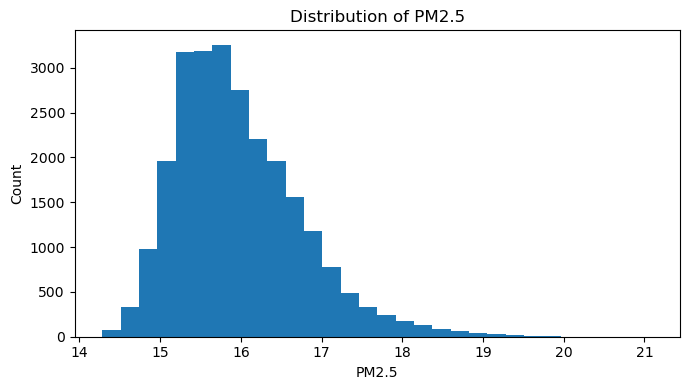

In [5]:
pm25 = gdf["PM25"]

print(pm25.describe())

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(pm25, bins=30)
ax.set_title("Distribution of PM2.5")
ax.set_xlabel("PM2.5")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

The histogram and summary statistics show that PM2.5 values are concentrated within a relatively narrow range, with a median of about 15.85 and a mean of about 15.98. The distribution is slightly right-skewed, with a smaller number of Output Areas showing higher PM2.5 values up to about 21.10. This means the target variable is not perfectly balanced across space, which may make prediction more difficult for the higher-value areas.

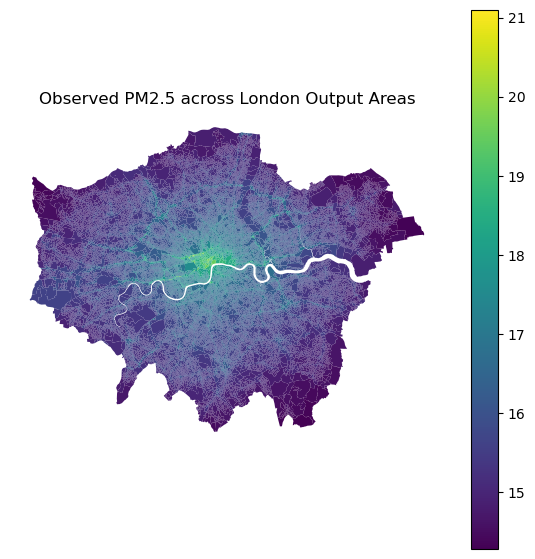

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

gdf.plot(
    column="PM25",
    ax=ax,
    legend=True
)

ax.set_title("Observed PM2.5 across London Output Areas")
ax.set_axis_off()

plt.show()

### Initial observation of PM2.5

The map shows that PM2.5 is not evenly distributed across London Output Areas. Higher values appear to be concentrated in more central parts of the city, while many outer areas show lower values. This suggests that PM2.5 has a clear spatial pattern rather than a random distribution. This matters for the next step because nearby areas may share similar environmental conditions, which supports the use of a spatial graph and message passing in the GNN model.

## 3. Build kNN graph

In [7]:
gdf["centroid"] = gdf.geometry.centroid

coords = np.column_stack([
    gdf["centroid"].x,
    gdf["centroid"].y
])

k = 8

knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
knn.fit(coords)

distances, indices = knn.kneighbors(coords)
nn_idx = indices[:, 1:]

edges = []
for i in range(len(coords)):
    for j in nn_idx[i]:
        edges.append((i, int(j)))
        edges.append((int(j), i))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("coords shape:", coords.shape)
print("edge_index shape:", edge_index.shape)
print("number of nodes:", len(coords))
print("number of directed edges:", edge_index.shape[1])

coords shape: (25053, 2)
edge_index shape: torch.Size([2, 400848])
number of nodes: 25053
number of directed edges: 400848


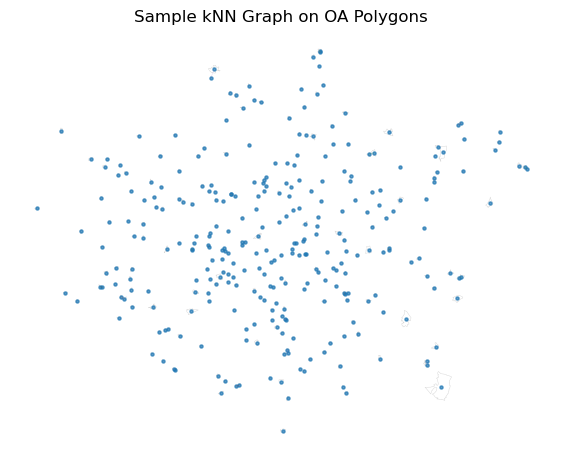

In [8]:
sample_n = 300
sample_idx = np.random.choice(len(gdf), size=sample_n, replace=False)

sample_gdf = gdf.iloc[sample_idx].copy()
sample_set = set(sample_idx.tolist())

fig, ax = plt.subplots(figsize=(7, 7))

sample_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgrey",
    linewidth=0.3
)

for i in sample_idx:
    for j in nn_idx[i]:
        if int(j) in sample_set:
            ax.plot(
                [coords[i, 0], coords[int(j), 0]],
                [coords[i, 1], coords[int(j), 1]],
                linewidth=0.3,
                alpha=0.3
            )

ax.scatter(
    coords[sample_idx, 0],
    coords[sample_idx, 1],
    s=5,
    alpha=0.7
)

ax.set_title("Sample kNN Graph on OA Polygons")
ax.set_axis_off()

plt.show()

### Graph construction

Each Output Area (OA) was treated as a node, and edges were defined using a centroid-based k-nearest neighbours graph with k = 8. This method is allowed by the assignment brief and provides a simple way to represent spatial relationships between nearby areas.

A kNN graph was used instead of polygon adjacency because London OAs are irregular in shape and size. Using k-nearest neighbours gives each node a comparable number of local connections, which makes the graph structure more consistent across the study area. Here, k = 8 was chosen as a simple balance: it keeps the graph local enough to reflect nearby conditions, while avoiding an overly sparse network.

This graph construction also follows the course logic that graphs represent spatial units as nodes and relationships as edges. In urban analysis, nearby places often share similar environmental conditions, so the kNN graph allows the GNN to pass and aggregate information between neighbouring OAs when predicting PM2.5.

## 4. Create PyG data and masks

In [9]:
X = torch.tensor(X_std.values, dtype=torch.float32)
y = torch.tensor(y_series.values, dtype=torch.float32).view(-1, 1)

data_knn = Data(x=X, edge_index=edge_index, y=y)

print(data_knn)
print("num_nodes:", data_knn.num_nodes)
print("num_edges:", data_knn.num_edges)
print("num_features:", data_knn.num_features)

Data(x=[25053, 60], edge_index=[2, 400848], y=[25053, 1])
num_nodes: 25053
num_edges: 400848
num_features: 60


### PyG data and data split

The node feature matrix X stores the 60 urban attributes for each Output Area, while y stores the observed PM2.5 values. These tensors are combined with edge_index in a PyTorch Geometric Data object, which provides the graph-structured input for node-level regression. The nodes are then divided into training, validation, and test sets using boolean masks. In this notebook, a 60% / 20% / 20% split is used. Although the assignment brief only explicitly requires a training and testing split, adding a validation set is useful for monitoring model learning before final evaluation.

In [10]:
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def make_masks(num_nodes: int, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(num_nodes)
    rng.shuffle(idx)

    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask

set_seed(42)

train_mask, val_mask, test_mask = make_masks(
    data_knn.num_nodes,
    train_ratio=0.6,
    val_ratio=0.2,
    seed=42
)

data_knn.train_mask = train_mask
data_knn.val_mask = val_mask
data_knn.test_mask = test_mask

print("Train nodes:", int(data_knn.train_mask.sum()))
print("Val nodes:", int(data_knn.val_mask.sum()))
print("Test nodes:", int(data_knn.test_mask.sum()))
print("Total nodes:", int(
    data_knn.train_mask.sum() +
    data_knn.val_mask.sum() +
    data_knn.test_mask.sum()
))

Train nodes: 15031
Val nodes: 5010
Test nodes: 5012
Total nodes: 25053


The boolean masks assign each Output Area to one of three subsets: training, validation, or test. In this notebook, the split is 60% / 20% / 20%, with a fixed random seed for reproducibility. This allows the models to be trained on one subset, monitored on another, and evaluated on unseen nodes at the end. The use of boolean masks is standard in PyTorch Geometric for node-level prediction tasks.

## 5. Define utilities and models

This section defines the utility functions and graph neural network models used for node-level regression. The utility functions calculate RMSE and R² for the training, validation, and test subsets, and they also store the learning curves during training. Two models are then defined: a two-layer Graph Convolutional Network (GCN) and a two-layer GraphSAGE model. This follows the assignment brief, which requires a basic GNN with node features, graph edges, and two graph convolution layers, and it is consistent with the course material on message passing and node information aggregation in GNNs.

In [11]:
@torch.no_grad()
def evaluate_regression(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)

    def rmse(mask):
        return torch.sqrt(F.mse_loss(pred[mask], y[mask])).item()

    return rmse(data.train_mask), rmse(data.val_mask), rmse(data.test_mask)


@torch.no_grad()
def evaluate_regression_r2(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)

    def r2(mask):
        y_true = y[mask]
        y_pred = pred[mask]
        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
        return (1 - ss_res / (ss_tot + 1e-12)).item()

    return r2(data.train_mask), r2(data.val_mask), r2(data.test_mask)


def plot_learning_curve(train_vals, val_vals, title, ylabel):
    plt.figure(figsize=(5.5, 3.2))
    plt.plot(train_vals, label="train")
    plt.plot(val_vals, label="val")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.legend()
    plt.show()


@torch.no_grad()
def get_test_predictions(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1).cpu().numpy()
    y_true = data.y.view(-1).cpu().numpy()
    test_mask = data.test_mask.cpu().numpy()
    return y_true[test_mask], pred[test_mask]


@torch.no_grad()
def get_all_predictions(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1).cpu().numpy()
    return pred

Two graph neural network models are used in this notebook: GCN and GraphSAGE. Both follow the assignment brief by using two graph convolution layers. In each model, the first layer transforms the 60 input features of each Output Area into a hidden representation, and the second layer outputs one predicted PM2.5 value for each node. ReLU activation and dropout are applied between the two layers. This design is consistent with the course explanation of GNNs as models that learn through message passing and node information aggregation across graph-connected spatial units.

In [12]:
class GCNReg(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class SAGEReg(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=32, dropout=0.2):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


def train_node_regression(
    model,
    data,
    lr=0.01,
    weight_decay=5e-4,
    epochs=150,
    print_every=30
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    train_rmse_list = []
    val_rmse_list = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        pred = model(data.x, data.edge_index).view(-1)
        y = data.y.view(-1)

        loss = F.mse_loss(pred[data.train_mask], y[data.train_mask])
        loss.backward()
        optimizer.step()

        train_rmse, val_rmse, _ = evaluate_regression(model, data)
        train_rmse_list.append(train_rmse)
        val_rmse_list.append(val_rmse)

        if epoch % print_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {loss.item():.4f} | "
                f"Train RMSE {train_rmse:.4f} | "
                f"Val RMSE {val_rmse:.4f}"
            )

    return model, train_rmse_list, val_rmse_list

## 6. Train GCN

Epoch 001 | Loss 269.9691 | Train RMSE 15.8054 | Val RMSE 15.8182
Epoch 030 | Loss 30.0433 | Train RMSE 5.2358 | Val RMSE 5.2076
Epoch 060 | Loss 8.6036 | Train RMSE 2.7040 | Val RMSE 2.7491
Epoch 090 | Loss 5.5892 | Train RMSE 2.1123 | Val RMSE 2.1485
Epoch 120 | Loss 4.4267 | Train RMSE 1.7997 | Val RMSE 1.8275
Epoch 150 | Loss 3.7518 | Train RMSE 1.6299 | Val RMSE 1.6569
Final (GCN) RMSE train/val/test: (1.6298582553863525, 1.656946063041687, 1.628548264503479)
Final (GCN) R2 train/val/test: (-3.2433762550354004, -3.5270137786865234, -3.507807731628418)


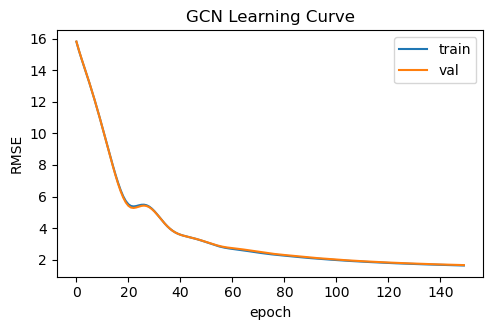

In [13]:
gcn_model = GCNReg(
    in_dim=data_knn.x.size(1),
    hidden_dim=32,
    dropout=0.2
)

gcn_model, train_rmse_gcn, val_rmse_gcn = train_node_regression(
    gcn_model,
    data_knn,
    lr=0.01,
    weight_decay=1e-4,
    epochs=150,
    print_every=30
)

gcn_rmse = evaluate_regression(gcn_model, data_knn)
gcn_r2 = evaluate_regression_r2(gcn_model, data_knn)

print("Final (GCN) RMSE train/val/test:", gcn_rmse)
print("Final (GCN) R2 train/val/test:", gcn_r2)

plot_learning_curve(
    train_rmse_gcn,
    val_rmse_gcn,
    "GCN Learning Curve",
    "RMSE"
)

## 7. Train GraphSAGE

Epoch 001 | Loss 252.8240 | Train RMSE 15.3264 | Val RMSE 15.3317
Epoch 030 | Loss 16.6995 | Train RMSE 3.7497 | Val RMSE 3.7350
Epoch 060 | Loss 4.9816 | Train RMSE 1.8701 | Val RMSE 1.8704
Epoch 090 | Loss 3.0306 | Train RMSE 1.3822 | Val RMSE 1.3859
Epoch 120 | Loss 2.1499 | Train RMSE 1.1228 | Val RMSE 1.1479
Epoch 150 | Loss 1.7495 | Train RMSE 0.9716 | Val RMSE 1.0026
Final (GraphSAGE) RMSE train/val/test: (0.9716073274612427, 1.002583622932434, 0.9653480648994446)
Final (GraphSAGE) R2 train/val/test: (-0.5079723596572876, -0.6574341058731079, -0.5839153528213501)


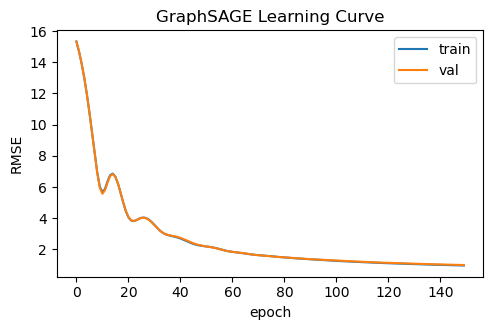

In [14]:
sage_model = SAGEReg(
    in_dim=data_knn.x.size(1),
    hidden_dim=32,
    dropout=0.2
)

sage_model, train_rmse_sage, val_rmse_sage = train_node_regression(
    sage_model,
    data_knn,
    lr=0.01,
    weight_decay=1e-4,
    epochs=150,
    print_every=30
)

sage_rmse = evaluate_regression(sage_model, data_knn)
sage_r2 = evaluate_regression_r2(sage_model, data_knn)

print("Final (GraphSAGE) RMSE train/val/test:", sage_rmse)
print("Final (GraphSAGE) R2 train/val/test:", sage_r2)

plot_learning_curve(
    train_rmse_sage,
    val_rmse_sage,
    "GraphSAGE Learning Curve",
    "RMSE"
)

## 8. Compare results and final figures

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

train_idx = data_knn.train_mask.cpu().numpy()
val_idx = data_knn.val_mask.cpu().numpy()
test_idx = data_knn.test_mask.cpu().numpy()

X_train = X_std.values[train_idx]
X_val = X_std.values[val_idx]
X_test = X_std.values[test_idx]

y_train = y_series.values[train_idx]
y_val = y_series.values[val_idx]
y_test = y_series.values[test_idx]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_val = lr_model.predict(X_val)
lr_pred_test = lr_model.predict(X_test)

lr_rmse = (
    np.sqrt(mean_squared_error(y_train, lr_pred_train)),
    np.sqrt(mean_squared_error(y_val, lr_pred_val)),
    np.sqrt(mean_squared_error(y_test, lr_pred_test))
)

lr_r2 = (
    r2_score(y_train, lr_pred_train),
    r2_score(y_val, lr_pred_val),
    r2_score(y_test, lr_pred_test)
)

print("Final (Linear Regression) RMSE train/val/test:", lr_rmse)
print("Final (Linear Regression) R2 train/val/test:", lr_r2)

Final (Linear Regression) RMSE train/val/test: (0.3860512718419206, 0.37386613559041176, 0.38048505050136366)
Final (Linear Regression) R2 train/val/test: (0.7619315623835257, 0.7695231358952564, 0.7539409889957391)


In [18]:
compare_df = pd.DataFrame({
    "Model": ["Linear Regression", "GCN", "GraphSAGE"],
    "Train_RMSE": [lr_rmse[0], gcn_rmse[0], sage_rmse[0]],
    "Val_RMSE": [lr_rmse[1], gcn_rmse[1], sage_rmse[1]],
    "Test_RMSE": [lr_rmse[2], gcn_rmse[2], sage_rmse[2]],
    "Train_R2": [lr_r2[0], gcn_r2[0], sage_r2[0]],
    "Val_R2": [lr_r2[1], gcn_r2[1], sage_r2[1]],
    "Test_R2": [lr_r2[2], gcn_r2[2], sage_r2[2]]
})

print(compare_df.round(3))

               Model  Train_RMSE  Val_RMSE  Test_RMSE  Train_R2  Val_R2  \
0  Linear Regression       0.386     0.374      0.380     0.762   0.770   
1                GCN       1.630     1.657      1.629    -3.243  -3.527   
2          GraphSAGE       0.972     1.003      0.965    -0.508  -0.657   

   Test_R2  
0    0.754  
1   -3.508  
2   -0.584  


### Overall model performance

The baseline linear regression model performed substantially better than both GNN models in this notebook. It achieved much lower RMSE values and clearly positive R² values across the training, validation, and test sets. In contrast, although GraphSAGE performed better than GCN, both graph models still produced negative test R² values.

This means that the main conclusion is not that the GNN improved prediction accuracy. Instead, the current results suggest that, under this graph construction and model setup, the graph-based models did not provide a predictive advantage over a simple non-graph baseline. GraphSAGE was the stronger of the two GNN models, but it still performed much worse than linear regression.

One possible explanation is that the centroid-based kNN graph captures only a simple form of spatial relationship. GNNs also depend on message passing and node information aggregation, which assume that neighbouring areas share useful information. For PM2.5 in London, that assumption may be too simple, and the model may also be affected by over-smoothing or sensitivity to graph construction. In this notebook, the graph models appear better suited to illustrating spatial learning ideas than to delivering the best predictive performance.

For interpretation, the following visual analysis focuses on GraphSAGE because it was the better-performing GNN, even though the baseline linear regression achieved the best overall predictive accuracy.

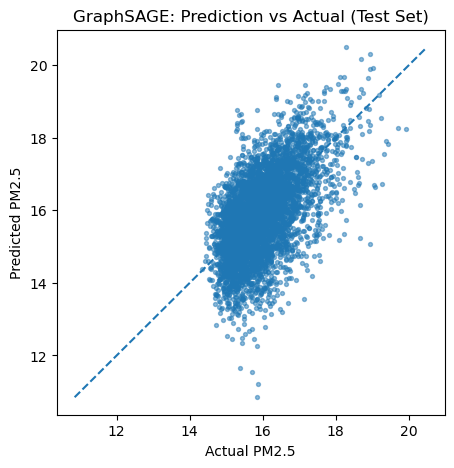

In [ ]:
# GraphSAGE final predictions
gdf_final = gdf.copy()
gdf_final["PM25_pred_sage"] = get_all_predictions(sage_model, data_knn)

# ---------- Figure 1: Prediction vs Actual (test set) ----------
y_test_sage, y_pred_test_sage = get_test_predictions(sage_model, data_knn)

plt.figure(figsize=(5, 5))
plt.scatter(y_test_sage, y_pred_test_sage, s=8, alpha=0.5)

line_min = min(y_test_sage.min(), y_pred_test_sage.min())
line_max = max(y_test_sage.max(), y_pred_test_sage.max())
plt.plot([line_min, line_max], [line_min, line_max], "--")

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("GraphSAGE: Prediction vs Actual (Test Set)")
plt.show()


### Test set prediction versus observed PM2.5

The prediction-versus-observed plot shows that the GraphSAGE model captures part of the general pattern in the test data, but the fit remains weak overall. Although predicted values tend to increase when observed PM2.5 values increase, many points are still far from the 1:1 reference line. This is consistent with the negative test R² and suggests that the model does not reproduce local PM2.5 variation accurately.

The plot also shows a clear smoothing pattern. Lower observed PM2.5 values are often over-predicted, while higher observed values are often under-predicted. This means that predictions are pulled towards the middle of the distribution rather than matching extreme values well.

A likely explanation is that the GNN aggregates information from neighbouring nodes through message passing, which can smooth local differences when the graph structure is simple or when nearby areas are not as similar as the model assumes. In this case, the model is better at recovering broad spatial tendencies than at predicting fine-grained variation for each Output Area.

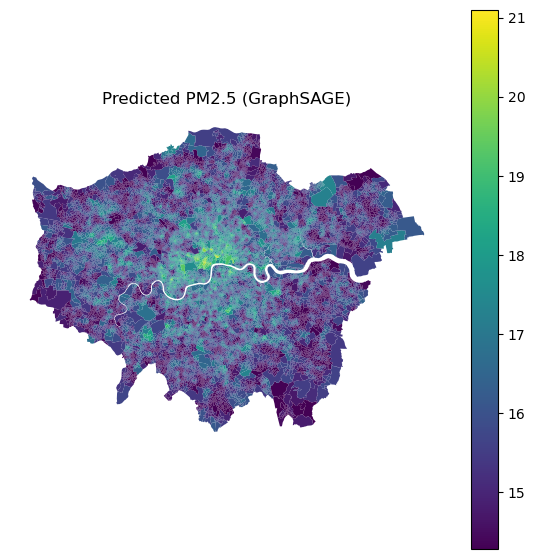

In [ ]:
# ---------- Figure 2: Predicted PM2.5 map ----------
vmin = gdf_final["PM25"].min()
vmax = gdf_final["PM25"].max()

fig, ax = plt.subplots(figsize=(7, 7))

gdf_final.plot(
    column="PM25_pred_sage",
    cmap="viridis",
    linewidth=0,
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=ax
)

ax.set_title("Predicted PM2.5 (GraphSAGE)")
ax.set_axis_off()

plt.show()

### Spatial distribution of predicted PM2.5

The predicted PM2.5 map suggests that the GraphSAGE model captures the broad spatial structure of air pollution across London, but it smooths much of the local variation. Predicted values are not randomly scattered. Instead, they form a coherent spatial pattern, which indicates that the graph-based model is using neighbourhood information rather than only isolated node attributes. However, the map is less useful for identifying fine-grained differences between nearby Output Areas, because the model tends to pull predictions towards the middle of the distribution. This is consistent with the prediction-versus-observed plot and the negative test R². In practical terms, the model appears better at recovering general spatial tendencies than at reproducing exact PM2.5 levels for each area.

This pattern also supports the course idea that spatial relationships matter in urban prediction. Nearby areas often share similar environmental conditions, so representing Output Areas as connected nodes can help the model learn broad spatial dependence. At the same time, the course materials warn that GNNs can be sensitive to graph construction and may suffer from over-smoothing. Those limitations are relevant here, because a simple centroid-based kNN graph may capture broad proximity well while missing more complex processes that shape PM2.5 in London.